# Lab 2 — Hybrid PUF (HPUF) and the Measure-then-Forge Attack
### Based on *"Quantum Lock: A Provable Quantum Communication Advantage"* (arXiv:2110.09469)

This notebook builds the **Hybrid PUF (HPUF)** construction from the paper (Construction 1) on top
of real Arbiter-PUF simulations from `pypuf`, encodes its output into genuine **BB84 qubit states**
using `qiskit`, simulates an eavesdropper ("Eve") running the paper's optimal single-copy
**measure-then-forge** attack, and finally compares a **logistic-regression (LR) modelling attack**
on the raw classical PUF (CPUF) versus on Eve's noisy quantum-derived database.

**Goal:** reproduce, at small scale, the qualitative result of Figures 5–6 of the paper — the HPUF
requires *more* challenge-response pairs (CRPs) than the underlying CPUF to reach the same forging
accuracy, because encoding the response into non-orthogonal quantum states injects irreducible
guessing noise that a classical eavesdropper cannot remove.

---
**Roles in this notebook** (see Appendix C.1 / Figure 4 of the paper):
- **PUF owner / manufacturer** — creates the classical PUF(s) (`pypuf` simulation).
- **HPUF** — wraps the CPUF and encodes its 2-bit output tuples into single-qubit BB84 states.
- **Eve (weak adversary)** — intercepts `(challenge, quantum state)` pairs, measures each qubit with
  the *optimal* single-copy discrimination strategy (Breidbart-basis measurement), and tries to
  forge the CPUF from her noisy classical database using logistic regression.


## 1. Setup

In [1]:
# If needed, uncomment and run once:
# !pip install pypuf qiskit qiskit-aer scikit-learn numpy matplotlib --break-system-packages

import numpy as np
import matplotlib.pyplot as plt

import pypuf.simulation
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from sklearn.linear_model import LogisticRegression

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)
SIM = AerSimulator()


## 2. The classical PUF (CPUF)

The paper's Construction 1 starts from a classical PUF $f:\{0,1\}^n \to \{0,1\}^{4m}$ and groups its
output bits into $2m$ pairs $(y_{2j-1}, y_{2j})$, one pair per output qubit.

For the smallest, most instructive case we take **$m=1$**: the HPUF outputs a *single* qubit per
challenge, built from a 2-bit CPUF output. Exactly as in the paper's own experiment
(Section 2.4), we obtain this 2-bit output from **two independent Arbiter PUFs**, $f_1$ and $f_2$
(each producing 1 bit — pypuf's `ArbiterPUF`). The bit $y_1=f_1(x)$ plays the role of the "hidden
value" bit and $y_2=f_2(x)$ plays the role of the "conjugate basis" bit in the BB84 encoding
(see Section 3 below).

> **Note on `k`-XOR PUFs.** The paper's real experiments use **XOR Arbiter PUFs** ($k=4,5$) as the
> underlying CPUF, since a single Arbiter PUF is too easy to model. A plain, linear logistic
> regression (as used below) works essentially only for $k=1$. Modelling a $k$-XOR PUF ($k>2$)
> needs a dedicated non-convex attack (several random restarts, a soft product-of-tanh objective,
> and orders of magnitude more CRPs — see Appendix, Section 7). We keep $k=1$ here so the whole
> pipeline runs in seconds and the security gap from quantum encoding is not obscured by the
> difficulty of attacking the CPUF itself; Section 7 shows how to plug in a stronger CPUF.


In [2]:
N_BITS = 64          # challenge length n

puf1 = pypuf.simulation.ArbiterPUF(n=N_BITS, seed=101)   # instantiates f1 -> y1
puf2 = pypuf.simulation.ArbiterPUF(n=N_BITS, seed=202)   # instantiates f2 -> y2

def gen_challenges(n_samples, rng=rng):
    '''Uniform random bipolar challenges in {-1, +1}^N_BITS.'''
    return rng.choice([-1, 1], size=(n_samples, N_BITS)).astype(np.float64)

def to_bit(resp_pm1):
    '''pypuf responses are bipolar (+1/-1); map to a classical bit (0/1).'''
    return (resp_pm1 < 0).astype(int)

def phi_vector(challenges):
    '''Additive-delay-model parity (phi) feature vector, reused from Lab 1.'''
    return pypuf.simulation.ArbiterPUF.transform_atf(challenges, 1)[:, 0, :]


## 3. HPUF construction — encoding classical outputs into BB84 qubits (Construction 1)

The paper's exact two-to-one encoding table (Eq. 14 / Construction 1) is:

| $(y_{2j-1}, y_{2j})$ | quantum state |
|---|---|
| $(0,0)$ | $\lvert 0\rangle$ |
| $(1,0)$ | $\lvert 1\rangle$ |
| $(0,1)$ | $\lvert +\rangle$ |
| $(1,1)$ | $\lvert -\rangle$ |

We implement this with **genuine Qiskit circuits**: apply `X` if $y_1=1$ (choosing $\lvert1\rangle$
over $\lvert0\rangle$), then apply `H` if $y_2=1$ (rotating into the conjugate $\{\lvert+\rangle,
\lvert-\rangle\}$ basis). Circuits are transpiled and executed **in a single batched call** on
`AerSimulator` for efficiency.


In [3]:
def build_hpuf_circuits(y1, y2):
    '''Build one 1-qubit state-preparation circuit per (y1, y2) tuple,
    following the HPUF encoding table of Construction 1 in the paper.'''
    circuits = []
    for b1, b2 in zip(y1, y2):
        qc = QuantumCircuit(1, 1)
        if b1 == 1:
            qc.x(0)     # select |1> instead of |0>
        if b2 == 1:
            qc.h(0)     # rotate into the conjugate (+/-) basis
        circuits.append(qc)
    return circuits


def query_hpuf(challenges, puf1=puf1, puf2=puf2):
    '''Query the HPUF: returns the true (y1, y2) bits and the corresponding
    BB84 state-preparation circuits (the actual quantum response the HPUF sends out).'''
    y1 = to_bit(puf1.eval(challenges).flatten())
    y2 = to_bit(puf2.eval(challenges).flatten())
    circuits = build_hpuf_circuits(y1, y2)
    return y1, y2, circuits


## 4. Eve's measure-then-forge attack (Lemma 1 / Lemma 2)

Eve is a **weak (non-adaptive) adversary**: she receives one copy of each quantum response and must
decide on a measurement *before* knowing the encoding basis. The paper shows (Lemma 1) that the
optimal single-copy strategy for guessing the *value* bit $y_{2j-1}$ from one of the four BB84
states is to measure in the **Breidbart basis** — the basis exactly "in between" the computational
and Hadamard bases, at 22.5° — giving a guessing probability

$$p_{\text{guess}} \le p(1+\sqrt{2}p) \quad\xrightarrow{p=0.5}\quad p_{\text{guess}} \le \cos^2(\pi/8) \approx 0.8536.$$

We implement this by applying `RY(-\pi/4)` before measuring in the computational basis — rotating
the Breidbart basis onto the $Z$ axis. Crucially, the *basis* bit $y_{2j}$ (which of
$\{0/1\}$ vs $\{+/-\}$ was used) carries essentially **no** information to this measurement, since it
is the very thing BB84-style conjugate coding is designed to hide from a single-copy measurement.


In [4]:
def eve_breidbart_attack(circuits):
    '''Eve's optimal weak-adversary measurement: rotate into the Breidbart basis
    (halfway between Z and X) and measure. Returns her noisy guess of y1 for each circuit.'''
    measured = []
    for qc in circuits:
        c = qc.copy()
        c.ry(-np.pi / 4, 0)
        c.measure(0, 0)
        measured.append(c)

    transpiled = transpile(measured, SIM)
    result = SIM.run(transpiled, shots=1, memory=True).result()
    guesses = np.array([int(result.get_memory(i)[0]) for i in range(len(circuits))])
    return guesses


## 5. Sanity check — recovering $y_1$ vs. $y_2$

Let's verify the theory numerically before running the full LR attack: Eve's measurement should
recover $y_1$ (the encoded value) with accuracy close to the Breidbart bound (~85%), while telling
her almost nothing about $y_2$ (the basis), i.e. close to 50% (random guessing).


In [5]:
N_CHECK = 4000
challenges = gen_challenges(N_CHECK)
y1, y2, circuits = query_hpuf(challenges)
eve_guess = eve_breidbart_attack(circuits)

y1_recovery = np.mean(eve_guess == y1)
y2_recovery = np.mean(eve_guess == y2)   # sanity: should be ~0.5, i.e. no leakage

print(f"Eve's accuracy recovering y1 (value bit):  {y1_recovery:.3f}   (theory bound ~0.8536)")
print(f"Eve's accuracy recovering y2 (basis bit):   {y2_recovery:.3f}   (should be ~0.5, i.e. hidden)")
print(f"Effective bit-flip / noise rate on y1:      {1 - y1_recovery:.3f}")


Eve's accuracy recovering y1 (value bit):  0.854   (theory bound ~0.8536)
Eve's accuracy recovering y2 (basis bit):   0.511   (should be ~0.5, i.e. hidden)
Effective bit-flip / noise rate on y1:      0.146


## 6. Logistic-regression modelling attack: CPUF vs. HPUF

We now run the **same LR attack function** in two settings:

1. **Direct CPUF attack** — Eve has plaintext CRPs $(x_i, y_1^{(i)})$ (as if she tapped the CPUF's
   output wire directly, no quantum encoding at all).
2. **HPUF measure-then-forge attack** — Eve only has $(x_i, \widehat{y_1}^{(i)})$, her noisy
   Breidbart-basis guesses obtained from the HPUF's quantum output.

In both cases the **forging accuracy is scored against the true CPUF response** $y_1$ — that is what
actually matters for an adversary trying to clone the device.


In [6]:
def run_ml_attack(phi_train, y_train, phi_test, y_test_true, max_iter=2000):
    '''Reusable LR modelling-attack helper (same role as Lab 1's run_ml_attack):
    trains on (phi_train, y_train) and reports accuracy against the *true* labels y_test_true.'''
    clf = LogisticRegression(max_iter=max_iter)
    clf.fit(phi_train, y_train)
    return clf.score(phi_test, y_test_true), clf


In [7]:
N_TRAIN = 6000
N_TEST = 2000

train_challenges = gen_challenges(N_TRAIN)
test_challenges = gen_challenges(N_TEST)

y1_train, _, circuits_train = query_hpuf(train_challenges)
y1_test = to_bit(puf1.eval(test_challenges).flatten())

eve_guess_train = eve_breidbart_attack(circuits_train)

phi_train = phi_vector(train_challenges)
phi_test = phi_vector(test_challenges)

acc_cpuf, _ = run_ml_attack(phi_train, y1_train, phi_test, y1_test)
acc_hpuf, _ = run_ml_attack(phi_train, eve_guess_train, phi_test, y1_test)

print(f"CPUF (direct) attack accuracy:          {acc_cpuf:.4f}")
print(f"HPUF (measure-then-forge) attack accuracy: {acc_hpuf:.4f}")
print(f"Security gap (accuracy drop):           {acc_cpuf - acc_hpuf:.4f}")


CPUF (direct) attack accuracy:          0.9915
HPUF (measure-then-forge) attack accuracy: 0.9625
Security gap (accuracy drop):           0.0290


## 7. Accuracy vs. number of CRPs (reproducing the shape of Fig. 5)

The paper's Figures 5–6 sweep the number of training CRPs and plot forging accuracy for the CPUF vs.
the HPUF. We reproduce the same qualitative curve here: at every training-set size, the HPUF curve
sits below the CPUF curve, and — per the Angluin–Laird (1988) random-classification-noise theory
already used in Lab 1 — the HPUF needs a multiplicatively larger number of CRPs
($\approx 1/(1-2p_{\text{flip}})^2$) to approach the same accuracy, rather than being capped at a
lower accuracy ceiling.


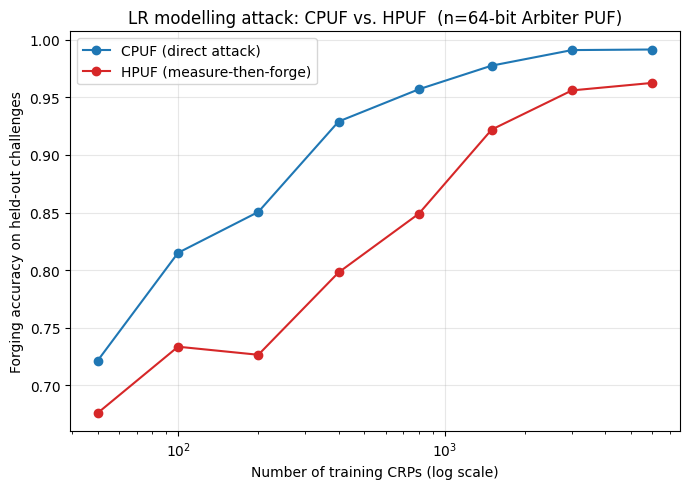

In [8]:
crp_grid = [50, 100, 200, 400, 800, 1500, 3000, 6000]

acc_cpuf_curve, acc_hpuf_curve = [], []
for n in crp_grid:
    a_c, _ = run_ml_attack(phi_train[:n], y1_train[:n], phi_test, y1_test)
    a_h, _ = run_ml_attack(phi_train[:n], eve_guess_train[:n], phi_test, y1_test)
    acc_cpuf_curve.append(a_c)
    acc_hpuf_curve.append(a_h)

plt.figure(figsize=(7, 5))
plt.plot(crp_grid, acc_cpuf_curve, "o-", color="tab:blue", label="CPUF (direct attack)")
plt.plot(crp_grid, acc_hpuf_curve, "o-", color="tab:red", label="HPUF (measure-then-forge)")
plt.xscale("log")
plt.xlabel("Number of training CRPs (log scale)")
plt.ylabel("Forging accuracy on held-out challenges")
plt.title(f"LR modelling attack: CPUF vs. HPUF  (n={N_BITS}-bit Arbiter PUF)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. (Optional / Advanced) Using a $k$-XOR Arbiter PUF as the underlying CPUF

To get closer to the paper's own experimental setup (Figures 5–6 use $k=4,5$-XOR Arbiter PUFs),
you need a dedicated attack: model each of the $k$ arbiter chains with its own weight vector
$w_i$ and train all of them jointly with gradient descent on the **soft-XOR** objective

$$\hat{y} = \prod_{i=1}^{k} \tanh(w_i \cdot \phi(x)), \qquad \mathcal{L} = \mathbb{E}\left[(\hat{y}-y)^2\right],$$

optimized with Adam and **several random restarts** (the loss landscape is highly non-convex).
This is provided below as a building block — plugging its output into `eve_breidbart_attack` and
`run_ml_attack` above reproduces the full pipeline for $k>1$. Be aware that for $k \ge 4$ this
typically needs on the order of $10^5$–$10^6$ CRPs and careful tuning, exactly as noted in the paper
(Section 2.4.2, Figure 8: $\sim 5{,}000$ CRPs to break the CPUF vs. $\sim 10^6$ to break the HLPUF).


In [9]:
def train_xor_lr_attack(phi, y_pm1, k, epochs=60, lr0=0.15, batch_size=512, seed=0):
    '''Gradient-based (Adam) soft-XOR logistic-regression-style attack for a k-XOR Arbiter PUF.
    y_pm1 must be bipolar (+1/-1) labels. Returns the learned weight matrix W of shape (k, n_features).
    For k>=4 this typically needs many random restarts and >>10^4 CRPs to converge — see note above.
    '''
    rs = np.random.default_rng(seed)
    n, d = phi.shape
    W = rs.normal(0, 1 / np.sqrt(d), size=(k, d))
    m, v = np.zeros_like(W), np.zeros_like(W)
    b1, b2, eps = 0.9, 0.999, 1e-8
    t = 0
    for ep in range(epochs):
        lr = lr0 * (0.97 ** ep)
        perm = rs.permutation(n)
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            X, yb = phi[idx], y_pm1[idx]
            A = np.tanh(X @ W.T)                       # (B, k)
            pred = np.prod(A, axis=1)                   # (B,)
            err = pred - yb
            with np.errstate(divide="ignore", invalid="ignore"):
                prod_others = np.where(np.abs(A) > 1e-6, pred[:, None] / A, 0.0)
            dZ = (2 * err[:, None] * prod_others) * (1 - A ** 2)
            grad = dZ.T @ X / len(idx)
            t += 1
            m[:] = b1 * m + (1 - b1) * grad
            v[:] = b2 * v + (1 - b2) * (grad ** 2)
            W -= lr * (m / (1 - b1 ** t)) / (np.sqrt(v / (1 - b2 ** t)) + eps)
    return W


def xor_attack_accuracy(W, phi, y_pm1):
    pred = np.sign(np.prod(np.tanh(phi @ W.T), axis=1))
    pred[pred == 0] = 1
    return np.mean(pred == y_pm1)


# Example usage (k=2 converges reliably; try k>=4 only with far more CRPs and restarts):
# k = 2
# xor_puf = pypuf.simulation.XORArbiterPUF(n=N_BITS, k=k, seed=99)
# c_train, c_test = gen_challenges(40000), gen_challenges(4000)
# r_train, r_test = xor_puf.eval(c_train).flatten(), xor_puf.eval(c_test).flatten()  # bipolar
# phi_tr, phi_te = phi_vector(c_train), phi_vector(c_test)
# best_acc = max(
#     xor_attack_accuracy(train_xor_lr_attack(phi_tr, r_train, k, seed=s), phi_te, r_test)
#     for s in range(5)
# )
# print("best k-XOR CPUF attack accuracy:", best_acc)


## 9. Summary

- The **HPUF** hides each 2-bit CPUF output pair inside one of the four non-orthogonal BB84 states
  $\{\lvert0\rangle,\lvert1\rangle,\lvert+\rangle,\lvert-\rangle\}$ (Construction 1).
- A weak adversary's **optimal single-copy measurement** (Breidbart basis) recovers the *value* bit
  with probability bounded by $p(1+\sqrt2 p)$ (Lemma 1) — about **85%** for an unbiased CPUF — and
  learns essentially **nothing** about the *basis* bit.
- Feeding this **noisy** classical database into the same logistic-regression attack used against
  the raw CPUF produces a measurably **lower** forging accuracy for a given number of CRPs, and — per
  random-classification-noise theory — requires proportionally more CRPs to close the gap, exactly
  the qualitative advantage claimed and simulated in the paper (Figs. 5–6).
- The **quantum lock** (HLPUF, Construction 2, not implemented in this notebook) is what turns this
  into security against a fully *adaptive* adversary — see Lab 2b / a follow-up notebook.
